In [10]:
!pip install psutil nvidia-ml-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00


In [30]:
from pathlib import Path
import json
import shutil
from datetime import datetime
import time

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


import cv2
cv2.setNumThreads(0)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from utilities.training_plots import plot_training_history, get_hardware_snapshot
from utilities.experiments import setup_experiment

In [24]:
PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
MANIFEST_DIR = DATA_DIR / "manifests"
NOTEBOOK_PATH = PROJECT_ROOT / "training_pipeline.ipynb"

FULL_MANIFEST = MANIFEST_DIR / "usable_multimodal_val_labelled_manifest.csv"

PATH_COL = "path"
LABEL_COL = "binary_label"
CONDITION_COL = "condition"

df = pd.read_csv(FULL_MANIFEST)

print("Manifest shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts(dropna=False))

print("\nCondition distribution:")
print(df[CONDITION_COL].value_counts(dropna=False))

display(df.head())

Manifest shape: (76928, 25)
Columns:
['path', 'relative_path', 'filename', 'file_size_bytes', 'file', 'original', 'split', 'modify_type', 'audio_model', 'fake_segments', 'audio_fake_segments', 'visual_fake_segments', 'video_frames', 'audio_frames', 'video_model', 'has_audio_stream', 'audio_decodable', 'audio_codec', 'sample_rate', 'channels', 'audio_duration', 'binary_label', 'visual_fake', 'audio_fake', 'condition']

Label distribution:
binary_label
1    56907
0    20021
Name: count, dtype: int64

Condition distribution:
condition
real                     20021
fake_video_fake_audio    19069
real_video_fake_audio    18938
fake_video_real_audio    18900
Name: count, dtype: int64


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,has_audio_stream,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,fake_video_fake_audio.mp4,1524347,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,both_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,1,1,fake_video_fake_audio
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,fake_video_real_audio.mp4,1517990,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,visual_modified,NaN,"[[0.65, 0.97], [1.851, 2.151]]",...,True,True,pcm_s16le,16000.0,1.0,18.048000,1,1,0,fake_video_real_audio
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real.mp4,real.mp4,2223274,lrs3/1Hok1iGFNSk/00004/real.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,17.920000,0,0,0,real
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,real_video_fake_audio.mp4,1527373,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,audio_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,0,1,real_video_fake_audio
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,00001_p1.mp4,2450165,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,NaN,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,50.596313,0,0,0,real


In [25]:
EXPERIMENT_ID = "002"
EXPERIMENT_NAME = "visual_convnext_group_disjoint_balanced20k"

NUM_FRAMES = 16
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 3

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

TRAIN_SIZE = 14000
VAL_SIZE = 3000
TEST_SIZE = 3000

NUM_WORKERS = 12
PREFETCH_FACTOR = 4

EXPERIMENT_CONFIG = {
    "task": "visual_only_binary_classification",
    "model": "FrameAverageConvNeXt-Tiny",
    "dataset": "AV-Deepfake1M++ validation subset",
    "split_type": "group_disjoint",
    "class_balance": "balanced_20k",
    "num_frames": NUM_FRAMES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "train_size": TRAIN_SIZE,
    "val_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "num_workers": NUM_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "comparison_to": "001_visual_convnext_random_balanced20k",
}

In [26]:
RUN_NAME, RUN_DIRS = setup_experiment(
    project_root=PROJECT_ROOT,
    experiment_id=EXPERIMENT_ID,
    experiment_name=EXPERIMENT_NAME,
    config=EXPERIMENT_CONFIG,
    notebook_path=None,
)

RUN_MANIFEST_DIR = RUN_DIRS["manifests"]
RESULTS_DIR = RUN_DIRS["results"]
CHECKPOINT_DIR = RUN_DIRS["checkpoints"]
PLOTS_DIR = RUN_DIRS["plots"]

print("RUN_NAME:", RUN_NAME)
print("Run directory:", RUN_DIRS["run"])
print("Manifest dir:", RUN_MANIFEST_DIR)
print("Results dir:", RESULTS_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Plots dir:", PLOTS_DIR)

Notebook snapshot saved: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k/notebook/002_visual_convnext_group_disjoint_balanced20k_notebook_snapshot.ipynb
Experiment created: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k
RUN_NAME: 002_visual_convnext_group_disjoint_balanced20k
Run directory: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k
Manifest dir: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k/manifests
Results dir: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k/results
Checkpoint dir: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k/checkpoints
Plots dir: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_group_disjoint_balanced20k/plots


In [27]:
df_exp = df[df[LABEL_COL].notna()].copy()
df_exp[LABEL_COL] = df_exp[LABEL_COL].astype(int)

def get_clip_group(row):
    if "relative_path" in row and pd.notna(row["relative_path"]):
        return str(Path(str(row["relative_path"])).parent)
    return str(Path(str(row[PATH_COL])).parent)

df_exp["clip_group"] = df_exp.apply(get_clip_group, axis=1)

print("Rows:", len(df_exp))
print("Unique clip groups:", df_exp["clip_group"].nunique())
print("\nLabels:")
print(df_exp[LABEL_COL].value_counts())
print("\nConditions:")
print(df_exp[CONDITION_COL].value_counts(dropna=False))

display(df_exp[["relative_path", "clip_group", LABEL_COL, CONDITION_COL]].head())

Rows: 76928
Unique clip groups: 51944

Labels:
binary_label
1    56907
0    20021
Name: count, dtype: int64

Conditions:
condition
real                     20021
fake_video_fake_audio    19069
real_video_fake_audio    18938
fake_video_real_audio    18900
Name: count, dtype: int64


,relative_path,clip_group,binary_label,condition
0,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004,1,fake_video_fake_audio
1,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,lrs3/1Hok1iGFNSk/00004,1,fake_video_real_audio
2,lrs3/1Hok1iGFNSk/00004/real.mp4,lrs3/1Hok1iGFNSk/00004,0,real
3,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004,1,real_video_fake_audio
4,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,lrs3/2YPHJdq5QWM/00001,0,real


In [28]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42,
)

train_idx, temp_idx = next(
    gss.split(
        df_exp,
        y=df_exp[LABEL_COL],
        groups=df_exp["clip_group"],
    )
)

train_full = df_exp.iloc[train_idx].copy()
temp_full = df_exp.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42,
)

val_idx, test_idx = next(
    gss2.split(
        temp_full,
        y=temp_full[LABEL_COL],
        groups=temp_full["clip_group"],
    )
)

val_full = temp_full.iloc[val_idx].copy()
test_full = temp_full.iloc[test_idx].copy()

print("Full group-disjoint split sizes:")
print("Train:", len(train_full))
print("Val:", len(val_full))
print("Test:", len(test_full))

Full group-disjoint split sizes:
Train: 53854
Val: 11625
Test: 11449


In [29]:
train_groups = set(train_full["clip_group"])
val_groups = set(val_full["clip_group"])
test_groups = set(test_full["clip_group"])

print("Train/val group overlap:", len(train_groups & val_groups))
print("Train/test group overlap:", len(train_groups & test_groups))
print("Val/test group overlap:", len(val_groups & test_groups))

Train/val group overlap: 0
Train/test group overlap: 0
Val/test group overlap: 0


In [31]:
def balanced_sample(split_df, n_total, label_col, random_state=42):
    n_per_class = n_total // 2
    parts = []

    for label in [0, 1]:
        label_df = split_df[split_df[label_col] == label].copy()
        n = min(n_per_class, len(label_df))

        if n < n_per_class:
            print(f"Warning: requested {n_per_class} for label {label}, but only {n} available.")

        parts.append(
            label_df.sample(n=n, random_state=random_state)
        )

    out = pd.concat(parts, ignore_index=True)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out

train_df = balanced_sample(train_full, TRAIN_SIZE, LABEL_COL)
val_df = balanced_sample(val_full, VAL_SIZE, LABEL_COL)
test_df = balanced_sample(test_full, TEST_SIZE, LABEL_COL)

print("Train labels:")
print(train_df[LABEL_COL].value_counts())

print("\nVal labels:")
print(val_df[LABEL_COL].value_counts())

print("\nTest labels:")
print(test_df[LABEL_COL].value_counts())

print("\nTrain conditions:")
print(train_df[CONDITION_COL].value_counts(dropna=False))

print("\nVal conditions:")
print(val_df[CONDITION_COL].value_counts(dropna=False))

print("\nTest conditions:")
print(test_df[CONDITION_COL].value_counts(dropna=False))

Train labels:
binary_label
0    7000
1    7000
Name: count, dtype: int64

Val labels:
binary_label
1    1500
0    1500
Name: count, dtype: int64

Test labels:
binary_label
1    1500
0    1500
Name: count, dtype: int64

Train conditions:
condition
real                     7000
real_video_fake_audio    2342
fake_video_fake_audio    2334
fake_video_real_audio    2324
Name: count, dtype: int64

Val conditions:
condition
real                     1500
real_video_fake_audio     503
fake_video_real_audio     502
fake_video_fake_audio     495
Name: count, dtype: int64

Test conditions:
condition
real                     1500
fake_video_real_audio     523
real_video_fake_audio     498
fake_video_fake_audio     479
Name: count, dtype: int64


In [32]:
train_groups = set(train_df["clip_group"])
val_groups = set(val_df["clip_group"])
test_groups = set(test_df["clip_group"])

print("Train/val group overlap:", len(train_groups & val_groups))
print("Train/test group overlap:", len(train_groups & test_groups))
print("Val/test group overlap:", len(val_groups & test_groups))

Train/val group overlap: 0
Train/test group overlap: 0
Val/test group overlap: 0


In [ ]:
train_csv = RUN_MANIFEST_DIR / "train.csv"
val_csv = RUN_MANIFEST_DIR / "val.csv"
test_csv = RUN_MANIFEST_DIR / "test.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Saved train:", train_csv)
print("Saved val:", val_csv)
print("Saved test:", test_csv)

In [ ]:
split_summary = {
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_label_counts": train_df[LABEL_COL].value_counts().to_dict(),
    "val_label_counts": val_df[LABEL_COL].value_counts().to_dict(),
    "test_label_counts": test_df[LABEL_COL].value_counts().to_dict(),
    "train_condition_counts": train_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "val_condition_counts": val_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "test_condition_counts": test_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "train_groups": train_df["clip_group"].nunique(),
    "val_groups": val_df["clip_group"].nunique(),
    "test_groups": test_df["clip_group"].nunique(),
    "train_val_group_overlap": len(set(train_df["clip_group"]) & set(val_df["clip_group"])),
    "train_test_group_overlap": len(set(train_df["clip_group"]) & set(test_df["clip_group"])),
    "val_test_group_overlap": len(set(val_df["clip_group"]) & set(test_df["clip_group"])),
}

with open(RUN_DIRS["run"] / "split_summary.json", "w") as f:
    json.dump(split_summary, f, indent=4)

split_summary

In [5]:
class VideoFrameDataset(Dataset):
    def __init__(self, csv_path, path_col, label_col, num_frames=16, image_size=224):
        self.df = pd.read_csv(csv_path)
        self.path_col = path_col
        self.label_col = label_col
        self.num_frames = num_frames

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.df)

    def _sample_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            raise RuntimeError(f"Could not open video: {video_path}")

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            raise RuntimeError(f"No frames found: {video_path}")

        indices = np.linspace(0, total_frames - 1, self.num_frames).astype(int)
        frames = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()

            if not ret:
                continue

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            raise RuntimeError(f"No frames sampled: {video_path}")

        while len(frames) < self.num_frames:
            frames.append(frames[-1])

        return torch.stack(frames)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = self._sample_frames(row[self.path_col])
        label = int(row[self.label_col])

        return frames, torch.tensor(label, dtype=torch.long)

In [6]:
class FrameAverageConvNeXt(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        self.backbone = convnext_tiny(weights=weights)

        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape

        x = x.reshape(B * T, C, H, W)

        frame_logits = self.backbone(x)          # [B*T, 2]
        frame_logits = frame_logits.reshape(B, T, -1)

        video_logits = frame_logits.mean(dim=1)  # [B, 2]

        return video_logits

In [7]:
train_dataset = VideoFrameDataset(
    train_csv,
    path_col=PATH_COL,
    label_col=LABEL_COL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
)

val_dataset = VideoFrameDataset(
    val_csv,
    path_col=PATH_COL,
    label_col=LABEL_COL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
)

test_dataset = VideoFrameDataset(
    test_csv,
    path_col=PATH_COL,
    label_col=LABEL_COL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR,
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = FrameAverageConvNeXt(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

best_val_f1 = -1
history = []
hardware_log_rows = []

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

Device: cuda


In [9]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    epoch=None,
    total_epochs=None,
    run_name=None,
    results_dir=None,
    hardware_log_rows=None,
    log_every=25,
):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    desc = f"Train {epoch}/{total_epochs}" if epoch is not None else "Train"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        leave=False,
    )

    epoch_start_time = time.time()

    for batch_idx, (frames, labels) in enumerate(progress_bar):
        batch_start_time = time.time()

        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(frames)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_time = time.time() - batch_start_time

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        # Only update visible metrics every N batches, not every batch.
        if batch_idx % log_every == 0 or batch_idx == len(loader) - 1:
            running_loss = total_loss / max(1, len(all_labels))
            running_acc = accuracy_score(all_labels, all_preds)
            running_f1 = f1_score(all_labels, all_preds, zero_division=0)

            gpu_allocated = (
                torch.cuda.memory_allocated() / 1024**3
                if device == "cuda" else 0
            )

            progress_bar.set_postfix_str(
                f"loss={running_loss:.4f} | "
                f"acc={running_acc:.4f} | "
                f"f1={running_f1:.4f} | "
                f"gpu={gpu_allocated:.1f}GB | "
                f"batch={batch_time:.2f}s"
            )

        # Hardware logging can still happen every N batches.
        if hardware_log_rows is not None and batch_idx % log_every == 0:
            hw = get_hardware_snapshot(device=device)

            hw.update({
                "run_name": run_name,
                "phase": "train",
                "epoch": epoch,
                "batch_idx": batch_idx,
                "batch_time_sec": batch_time,
                "running_loss": total_loss / max(1, len(all_labels)),
            })

            hardware_log_rows.append(hw)

            if results_dir is not None and run_name is not None:
                pd.DataFrame(hardware_log_rows).to_csv(
                    Path(results_dir) / f"{run_name}_hardware_log.csv",
                    index=False
                )

    epoch_time = time.time() - epoch_start_time

    return {
        "loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(all_labels, all_preds),
        "balanced_acc": balanced_accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "epoch_time_sec": epoch_time,
    }


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device,
    split_name="Val",
    return_outputs=False,
    run_name=None,
    results_dir=None,
    hardware_log_rows=None,
    epoch=None,
    log_every=25,
):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    progress_bar = tqdm(
        loader,
        desc=split_name,
        total=len(loader),
        leave=False,
    )

    eval_start_time = time.time()

    for batch_idx, (frames, labels) in enumerate(progress_bar):
        batch_start_time = time.time()

        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(frames)
            loss = criterion(logits, labels)

        batch_time = time.time() - batch_start_time

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if batch_idx % log_every == 0 or batch_idx == len(loader) - 1:
            running_loss = total_loss / max(1, len(all_labels))
            running_acc = accuracy_score(all_labels, all_preds)
            running_f1 = f1_score(all_labels, all_preds, zero_division=0)

            progress_bar.set_postfix_str(
                f"loss={running_loss:.4f} | "
                f"acc={running_acc:.4f} | "
                f"f1={running_f1:.4f} | "
                f"batch={batch_time:.2f}s"
            )

        if hardware_log_rows is not None and batch_idx % log_every == 0:
            hw = get_hardware_snapshot(device=device)

            hw.update({
                "run_name": run_name,
                "phase": split_name,
                "epoch": epoch,
                "batch_idx": batch_idx,
                "batch_time_sec": batch_time,
                "running_loss": total_loss / max(1, len(all_labels)),
            })

            hardware_log_rows.append(hw)

            if results_dir is not None and run_name is not None:
                pd.DataFrame(hardware_log_rows).to_csv(
                    Path(results_dir) / f"{run_name}_hardware_log.csv",
                    index=False
                )

    eval_time = time.time() - eval_start_time

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(all_labels, all_preds),
        "balanced_acc": balanced_accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "eval_time_sec": eval_time,
    }

    try:
        metrics["auc"] = roc_auc_score(all_labels, all_probs)
    except ValueError:
        metrics["auc"] = None

    if return_outputs:
        return metrics, all_labels, all_preds, all_probs

    return metrics

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



========== Epoch 1/3 ==========


Validation epoch 1/3: 100%|██████████| 188/188 [09:45<00:00,  3.12s/it, loss=0.6450 | acc=0.6773 | f1=0.6078 | batch=0.03s]


{'epoch': 1, 'train_loss': 0.32306819599866865, 'train_acc': 0.8042142857142857, 'train_balanced_acc': 0.8042142857142858, 'train_f1': 0.80113182906479, 'train_precision': 0.8139466312840926, 'train_recall': 0.7887142857142857, 'train_epoch_time_sec': 2397.515645503998, 'val_loss': 0.6450193277994791, 'val_acc': 0.6773333333333333, 'val_balanced_acc': 0.6773333333333333, 'val_f1': 0.6077795786061588, 'val_precision': 0.7747933884297521, 'val_recall': 0.5, 'val_eval_time_sec': 585.7180752754211, 'val_auc': 0.820892}


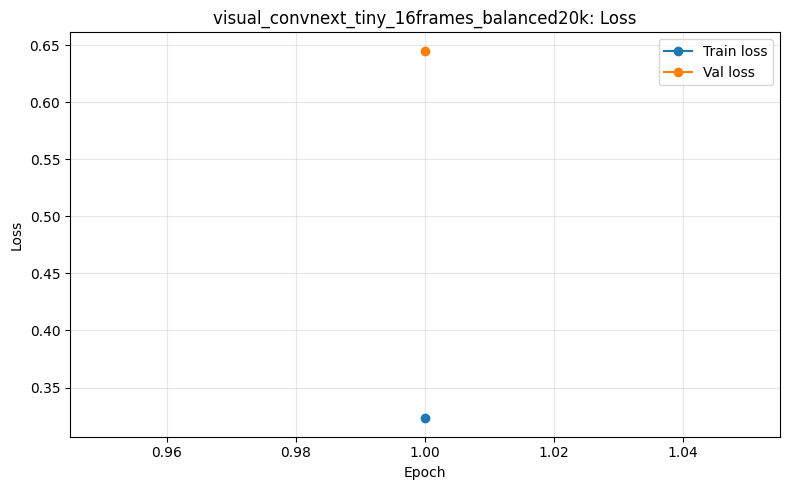

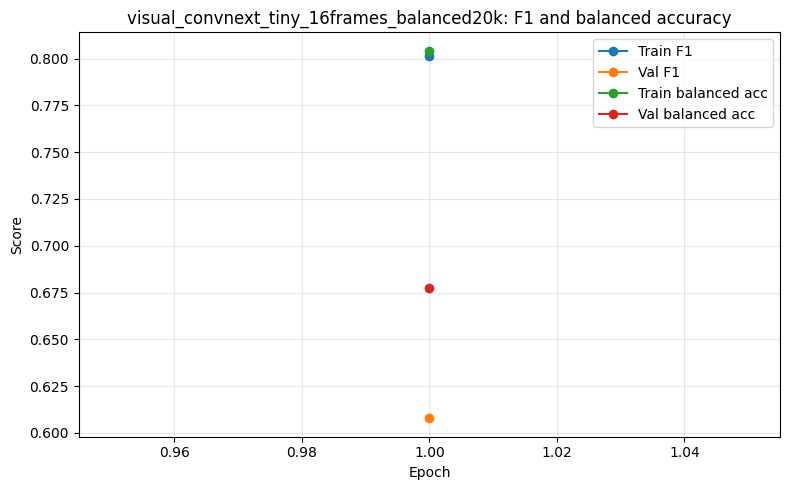

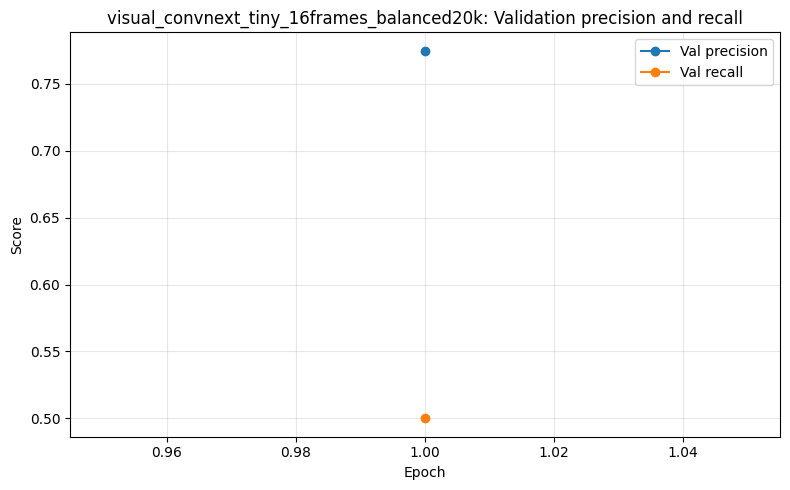

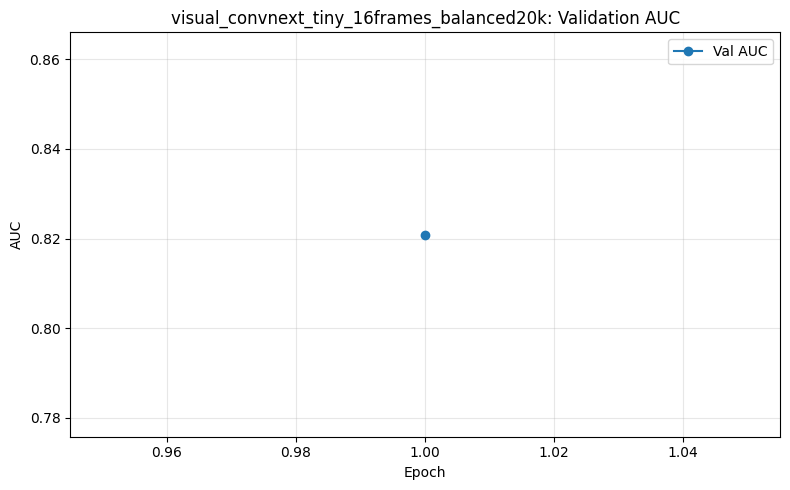

Saved best checkpoint: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/checkpoints/visual_convnext_tiny_16frames_balanced20k_best.pt

========== Epoch 2/3 ==========


Validation epoch 2/3: 100%|██████████| 188/188 [09:57<00:00,  3.18s/it, loss=0.2111 | acc=0.8593 | f1=0.8728 | batch=0.01s]


{'epoch': 2, 'train_loss': 0.2281001180580684, 'train_acc': 0.8625714285714285, 'train_balanced_acc': 0.8625714285714285, 'train_f1': 0.8613033448673587, 'train_precision': 0.869324796274738, 'train_recall': 0.8534285714285714, 'train_epoch_time_sec': 2407.640122652054, 'val_loss': 0.21108022451400757, 'val_acc': 0.8593333333333333, 'val_balanced_acc': 0.8593333333333333, 'val_f1': 0.8728149487643159, 'val_precision': 0.7964796479647965, 'val_recall': 0.9653333333333334, 'val_eval_time_sec': 597.9044892787933, 'val_auc': 0.9619111111111112}


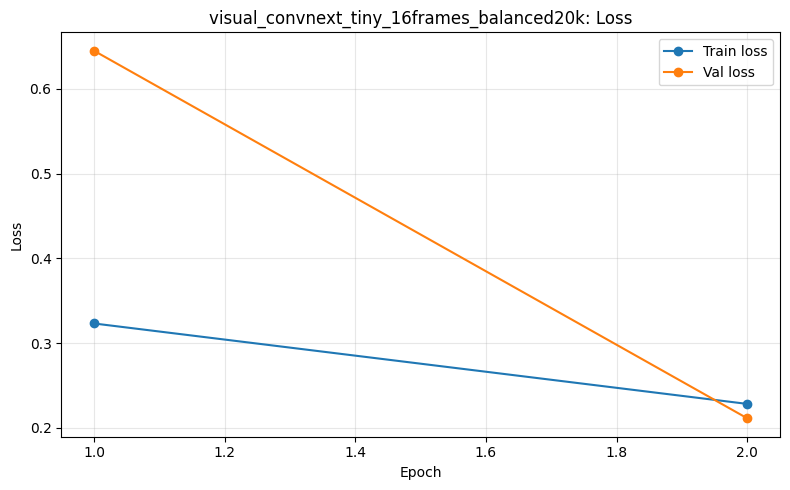

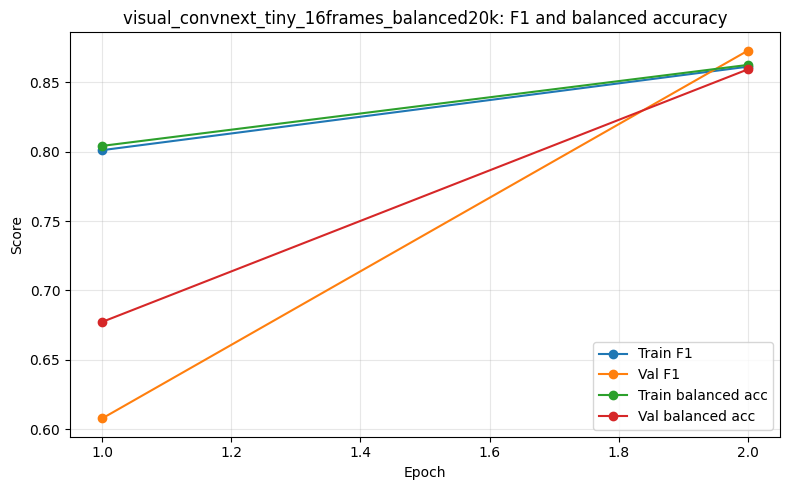

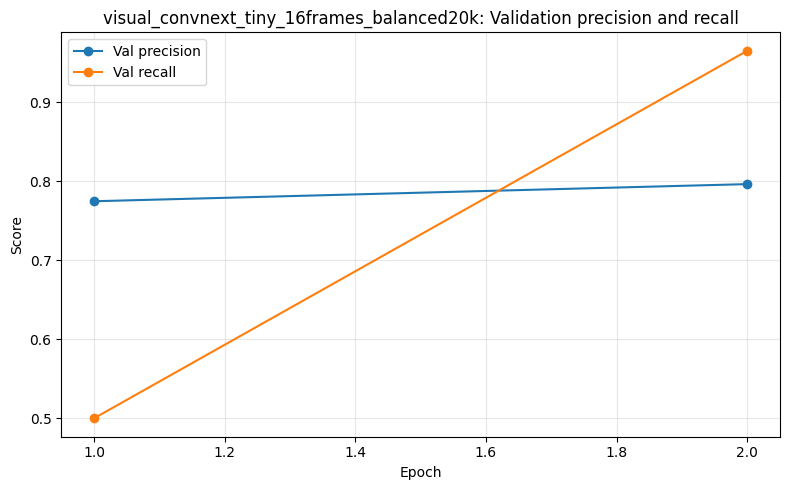

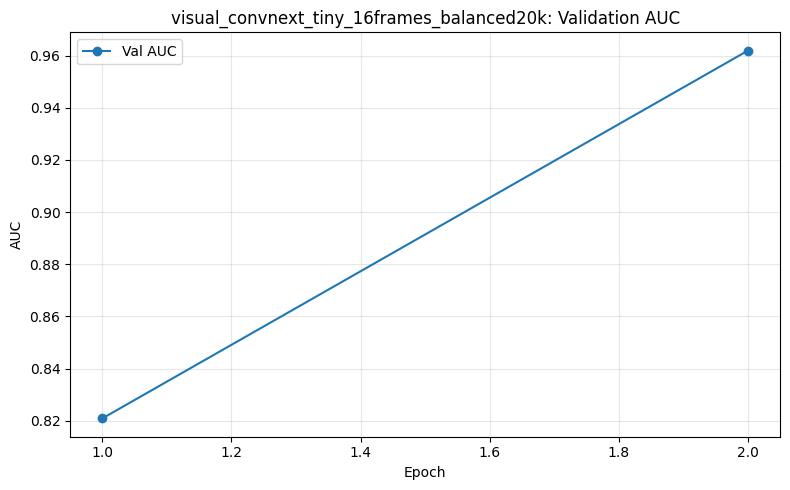

Saved best checkpoint: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/checkpoints/visual_convnext_tiny_16frames_balanced20k_best.pt

========== Epoch 3/3 ==========


Validation epoch 3/3: 100%|██████████| 188/188 [09:43<00:00,  3.10s/it, loss=0.2143 | acc=0.8627 | f1=0.8431 | batch=0.01s]


{'epoch': 3, 'train_loss': 0.19450731530359813, 'train_acc': 0.8821428571428571, 'train_balanced_acc': 0.8821428571428571, 'train_f1': 0.883753698745949, 'train_precision': 0.8718376424798443, 'train_recall': 0.896, 'train_epoch_time_sec': 2416.7696335315704, 'val_loss': 0.21434653866291045, 'val_acc': 0.8626666666666667, 'val_balanced_acc': 0.8626666666666667, 'val_f1': 0.8431073876618431, 'val_precision': 0.9831261101243339, 'val_recall': 0.738, 'val_eval_time_sec': 583.6845331192017, 'val_auc': 0.963424}


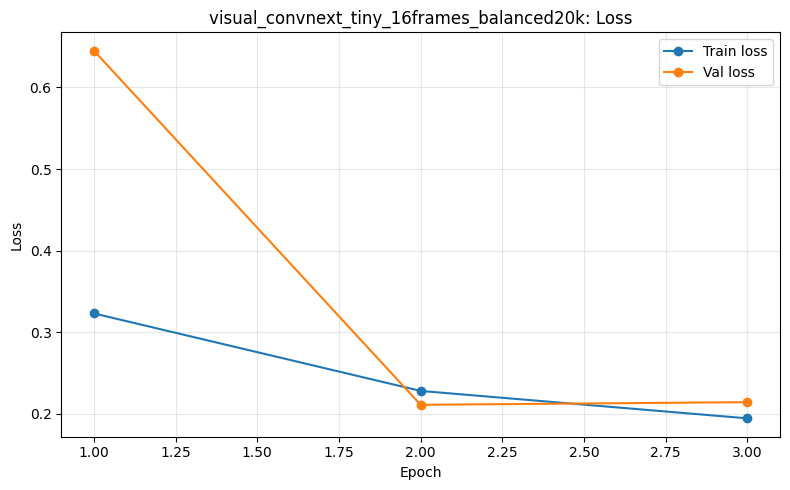

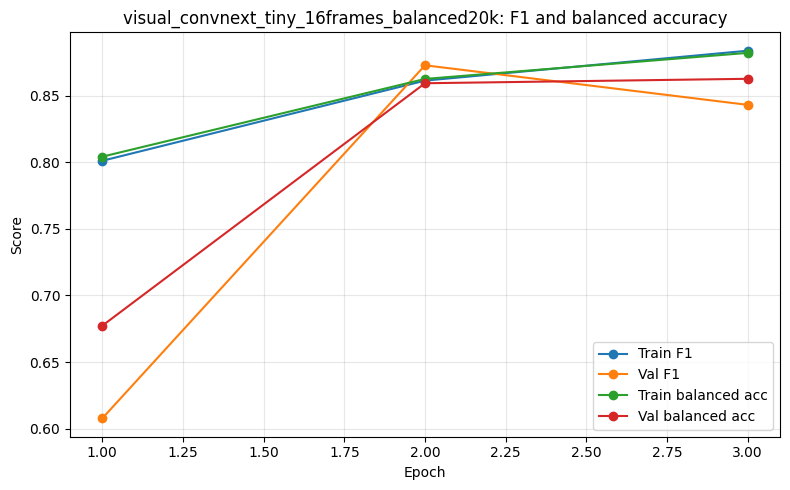

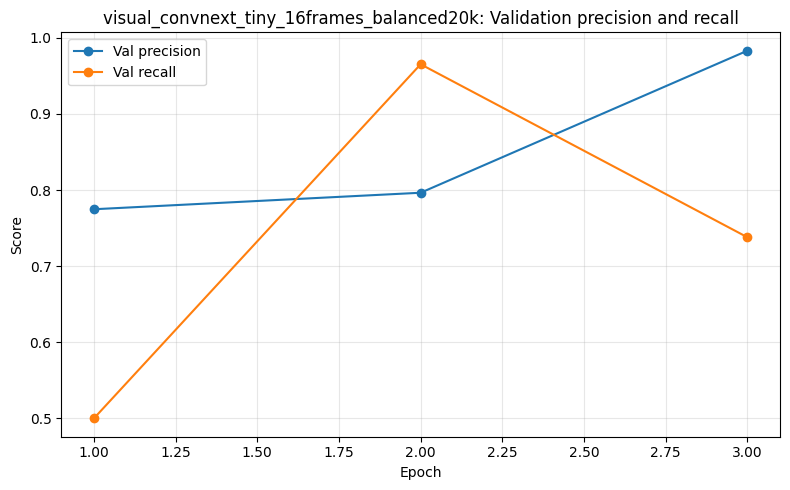

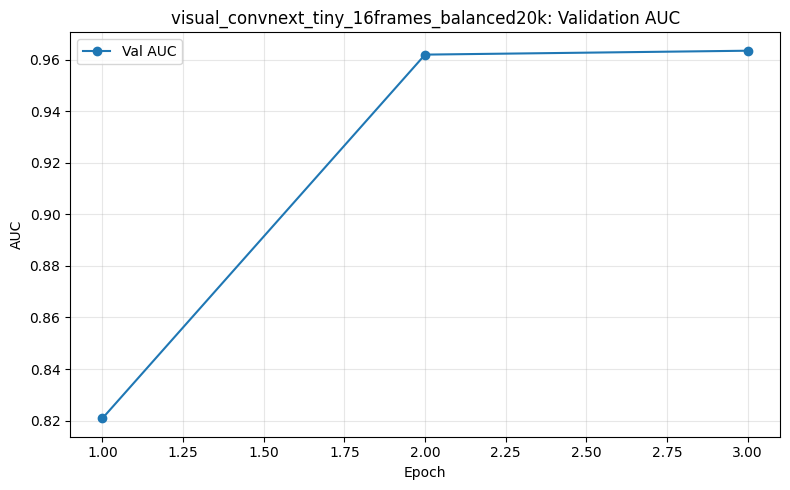

,timestamp,cpu_percent,ram_used_gb,ram_total_gb,ram_percent,torch_gpu_allocated_gb,torch_gpu_reserved_gb,torch_gpu_max_allocated_gb,nvml_gpu_used_gb,nvml_gpu_total_gb,nvml_gpu_util_percent,nvml_gpu_mem_util_percent,gpu_temp_c,gpu_power_w,run_name,phase,epoch,batch_idx,batch_time_sec,running_loss
0,1.783907e+09,7.0,25.853069,1510.354694,2.4,0.579467,16.119141,14.995591,17.334961,80.0,0,0,40,71.062,visual_convnext_tiny_16frames_balanced20k,train,1,0,7.095788,0.736465
1,1.783907e+09,7.3,25.653561,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,91,49,43,244.722,visual_convnext_tiny_16frames_balanced20k,train,1,10,0.261137,0.708314
2,1.783907e+09,7.3,25.561382,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,73,35,44,249.555,visual_convnext_tiny_16frames_balanced20k,train,1,20,0.240466,0.699531
3,1.783907e+09,7.2,25.659195,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,82,41,44,87.067,visual_convnext_tiny_16frames_balanced20k,train,1,30,0.243598,0.699340
4,1.783907e+09,7.1,25.740612,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,0,0,42,71.632,visual_convnext_tiny_16frames_balanced20k,train,1,40,0.260456,0.697935


['timestamp', 'cpu_percent', 'ram_used_gb', 'ram_total_gb', 'ram_percent', 'torch_gpu_allocated_gb', 'torch_gpu_reserved_gb', 'torch_gpu_max_allocated_gb', 'nvml_gpu_used_gb', 'nvml_gpu_total_gb', 'nvml_gpu_util_percent', 'nvml_gpu_mem_util_percent', 'gpu_temp_c', 'gpu_power_w', 'run_name', 'phase', 'epoch', 'batch_idx', 'batch_time_sec', 'running_loss']


In [12]:
for epoch in range(1, EPOCHS + 1):
    print(f"\n========== Epoch {epoch}/{EPOCHS} ==========")

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epoch=epoch,
        total_epochs=EPOCHS,
        run_name=RUN_NAME,
        results_dir=RESULTS_DIR,
        hardware_log_rows=hardware_log_rows,
        log_every=25,
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        split_name=f"Val {epoch}/{EPOCHS}",
        run_name=RUN_NAME,
        results_dir=RESULTS_DIR,
        hardware_log_rows=hardware_log_rows,
        epoch=epoch,
        log_every=25,
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(row)
    history_df = pd.DataFrame(history)

    history_path = RESULTS_DIR / f"{RUN_NAME}_history.csv"
    history_df.to_csv(history_path, index=False)

    hardware_path = RESULTS_DIR / f"{RUN_NAME}_hardware_log.csv"
    pd.DataFrame(hardware_log_rows).to_csv(hardware_path, index=False)

    print(row)

    plot_training_history(history_df, PLOTS_DIR, RUN_NAME)

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]

        checkpoint_path = CHECKPOINT_DIR / f"{RUN_NAME}_best.pt"

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_metrics": val_metrics,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "model": "frame_average_convnext_tiny",
            "run_name": RUN_NAME,
            "gpu_peak_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3 if device == "cuda" else None,
        }, checkpoint_path)

        print("Saved best checkpoint:", checkpoint_path)

,timestamp,cpu_percent,ram_used_gb,ram_total_gb,ram_percent,torch_gpu_allocated_gb,torch_gpu_reserved_gb,torch_gpu_max_allocated_gb,nvml_gpu_used_gb,nvml_gpu_total_gb,nvml_gpu_util_percent,nvml_gpu_mem_util_percent,gpu_temp_c,gpu_power_w,run_name,phase,epoch,batch_idx,batch_time_sec,running_loss
0,1.783907e+09,7.0,25.853069,1510.354694,2.4,0.579467,16.119141,14.995591,17.334961,80.0,0,0,40,71.062,visual_convnext_tiny_16frames_balanced20k,train,1,0,7.095788,0.736465
1,1.783907e+09,7.3,25.653561,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,91,49,43,244.722,visual_convnext_tiny_16frames_balanced20k,train,1,10,0.261137,0.708314
2,1.783907e+09,7.3,25.561382,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,73,35,44,249.555,visual_convnext_tiny_16frames_balanced20k,train,1,20,0.240466,0.699531
3,1.783907e+09,7.2,25.659195,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,82,41,44,87.067,visual_convnext_tiny_16frames_balanced20k,train,1,30,0.243598,0.699340
4,1.783907e+09,7.1,25.740612,1510.354694,2.4,0.578918,16.123047,15.211074,17.338867,80.0,0,0,42,71.632,visual_convnext_tiny_16frames_balanced20k,train,1,40,0.260456,0.697935


['timestamp', 'cpu_percent', 'ram_used_gb', 'ram_total_gb', 'ram_percent', 'torch_gpu_allocated_gb', 'torch_gpu_reserved_gb', 'torch_gpu_max_allocated_gb', 'nvml_gpu_used_gb', 'nvml_gpu_total_gb', 'nvml_gpu_util_percent', 'nvml_gpu_mem_util_percent', 'gpu_temp_c', 'gpu_power_w', 'run_name', 'phase', 'epoch', 'batch_idx', 'batch_time_sec', 'running_loss']


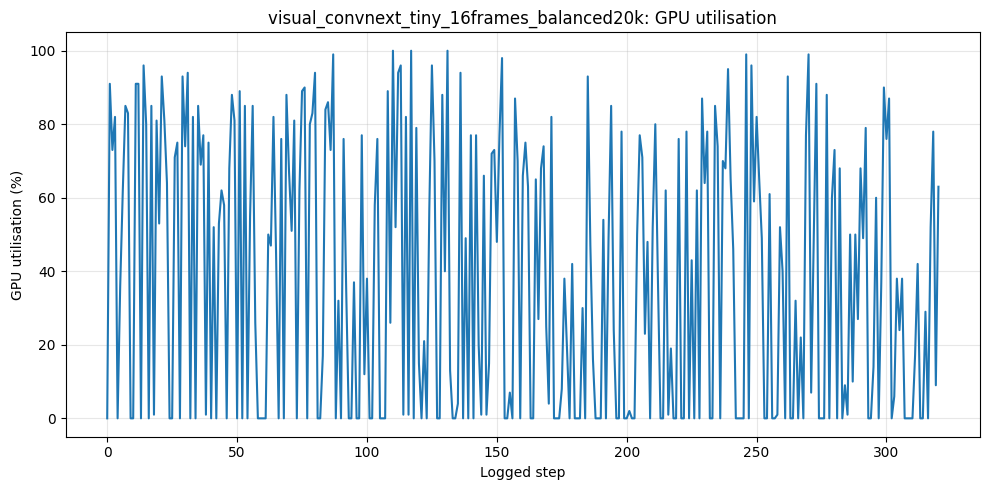

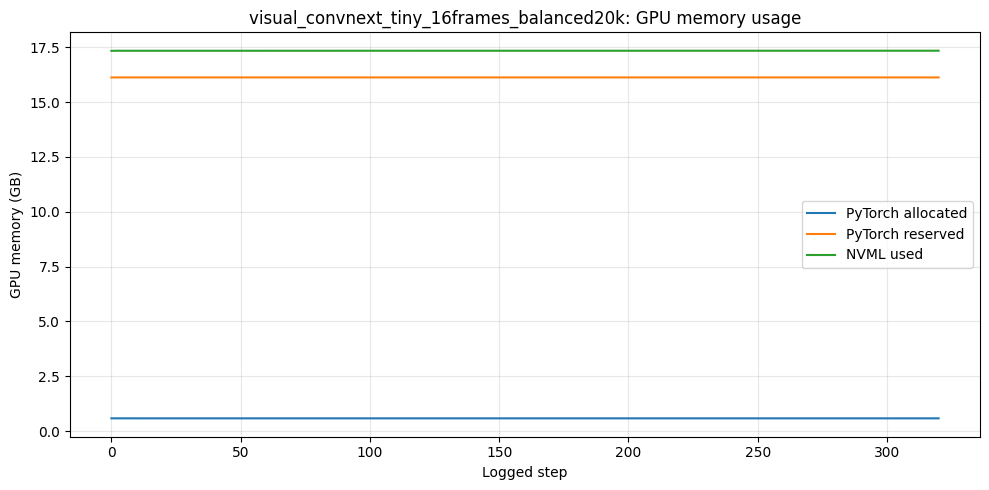

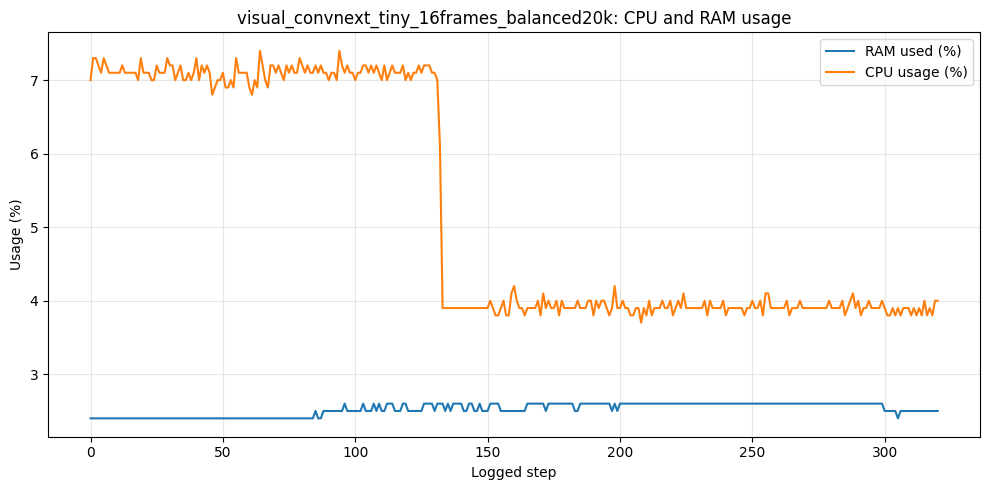

In [13]:
hardware_log_path = RESULTS_DIR / f"{RUN_NAME}_hardware_log.csv"
hardware_df = pd.read_csv(hardware_log_path)

display(hardware_df.head())
print(hardware_df.columns.tolist())

plt.figure(figsize=(10, 5))
plt.plot(hardware_df["nvml_gpu_util_percent"])
plt.xlabel("Logged step")
plt.ylabel("GPU utilisation (%)")
plt.title(f"{RUN_NAME}: GPU utilisation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_gpu_utilisation.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hardware_df["torch_gpu_allocated_gb"], label="PyTorch allocated")
plt.plot(hardware_df["torch_gpu_reserved_gb"], label="PyTorch reserved")
plt.plot(hardware_df["nvml_gpu_used_gb"], label="NVML used")
plt.xlabel("Logged step")
plt.ylabel("GPU memory (GB)")
plt.title(f"{RUN_NAME}: GPU memory usage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_gpu_memory.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hardware_df["ram_percent"], label="RAM used (%)")
plt.plot(hardware_df["cpu_percent"], label="CPU usage (%)")
plt.xlabel("Logged step")
plt.ylabel("Usage (%)")
plt.title(f"{RUN_NAME}: CPU and RAM usage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_cpu_ram_usage.png", dpi=200)
plt.show()

In [16]:
checkpoint_path = CHECKPOINT_DIR / f"{RUN_NAME}_best.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

test_metrics, y_true, y_pred, y_prob = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    split_name="Test",
    return_outputs=True,
    run_name=RUN_NAME,
    results_dir=RESULTS_DIR,
    hardware_log_rows=hardware_log_rows,
    epoch="test",
    log_every=25,
)

print(test_metrics)

pd.DataFrame([test_metrics]).to_csv(
    RESULTS_DIR / f"{RUN_NAME}_test_metrics.csv",
    index=False,
)

Test: 100%|██████████| 188/188 [09:27<00:00,  3.02s/it, loss=0.2001 | acc=0.8733 | f1=0.8846 | batch=0.01s]

{'loss': 0.2001197400490443, 'acc': 0.8733333333333333, 'balanced_acc': 0.8733333333333333, 'f1': 0.8845686512758202, 'precision': 0.8125, 'recall': 0.9706666666666667, 'eval_time_sec': 567.0901246070862, 'auc': 0.9668535555555555}


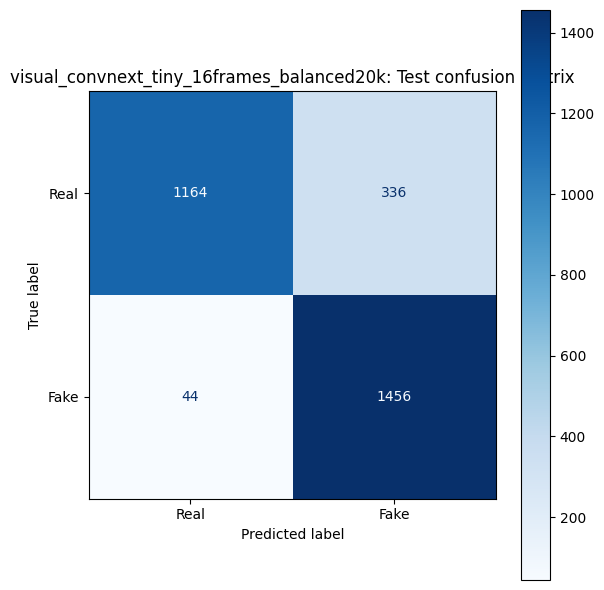

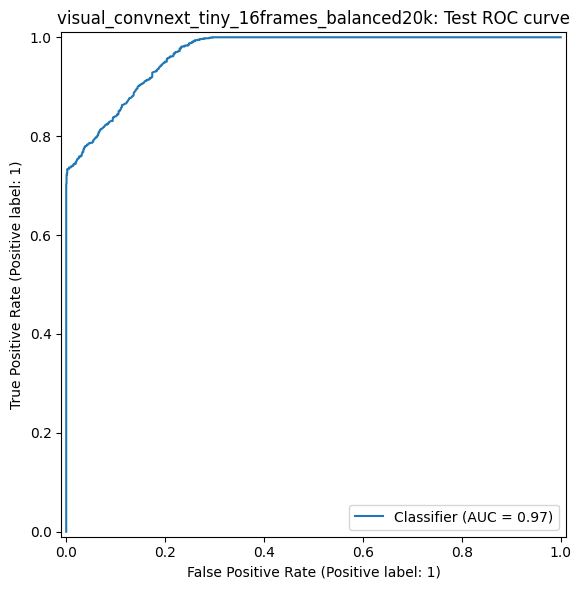

In [17]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Real", "Fake"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title(f"{RUN_NAME}: Test confusion matrix")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_confusion_matrix.png", dpi=200)
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_predictions(
    y_true,
    y_prob,
    ax=ax
)

plt.title(f"{RUN_NAME}: Test ROC curve")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_roc_curve.png", dpi=200)
plt.show()

In [18]:
test_results_df = pd.read_csv(test_csv).reset_index(drop=True)

test_results_df["y_true"] = y_true
test_results_df["y_pred"] = y_pred
test_results_df["fake_probability"] = y_prob

test_predictions_path = RESULTS_DIR / f"{RUN_NAME}_test_predictions.csv"
test_results_df.to_csv(test_predictions_path, index=False)

print("Saved predictions:", test_predictions_path)

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,condition,n,acc,balanced_acc,f1,precision,recall,mean_fake_probability
0,fake_video_fake_audio,533,0.971857,0.971857,0.985728,1.0,0.971857,0.868164
1,fake_video_real_audio,500,0.964000,0.964000,0.981670,1.0,0.964000,0.876953
2,real,1500,0.776000,0.776000,0.000000,0.0,0.000000,0.159546
3,real_video_fake_audio,467,0.976445,0.976445,0.988082,1.0,0.976445,0.875488


In [ ]:
condition_rows = []

for condition, group in test_results_df.groupby(CONDITION_COL):
    true_labels = group["y_true"].unique().tolist()
    predicted_fake_rate = group["y_pred"].mean()
    mean_fake_probability = group["fake_probability"].mean()

    if len(true_labels) == 1:
        true_label = int(true_labels[0])

        if true_label == 1:
            condition_success_rate = predicted_fake_rate
            interpretation = "fake recall"
        else:
            condition_success_rate = 1 - predicted_fake_rate
            interpretation = "real recall"
    else:
        true_label = "mixed"
        condition_success_rate = accuracy_score(group["y_true"], group["y_pred"])
        interpretation = "accuracy"

    condition_rows.append({
        "condition": condition,
        "n": len(group),
        "true_label": true_label,
        "condition_success_rate": condition_success_rate,
        "interpretation": interpretation,
        "predicted_fake_rate": predicted_fake_rate,
        "mean_fake_probability": mean_fake_probability,
    })

condition_metrics_df = pd.DataFrame(condition_rows)
condition_metrics_df = condition_metrics_df.sort_values("condition")

condition_metrics_path = RESULTS_DIR / f"{RUN_NAME}_condition_metrics_clean.csv"
condition_metrics_df.to_csv(condition_metrics_path, index=False)

display(condition_metrics_df)
print("Saved:", condition_metrics_path)

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["condition_success_rate"])
plt.xlabel("Condition")
plt.ylabel("Success rate")
plt.title(f"{RUN_NAME}: Success rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_condition_success_rate.png", dpi=200)
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["mean_fake_probability"])
plt.xlabel("Condition")
plt.ylabel("Mean predicted fake probability")
plt.title(f"{RUN_NAME}: Mean fake probability by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_condition_fake_probability.png", dpi=200)
plt.show()

In [ ]:
def create_experiment_index(run_dirs):
    run_dir = Path(run_dirs["run"])
    rows = []

    for section, folder in run_dirs.items():
        folder = Path(folder)

        if not folder.exists() or not folder.is_dir():
            continue

        for file in folder.rglob("*"):
            if file.is_file():
                rows.append({
                    "section": section,
                    "filename": file.name,
                    "path": str(file),
                    "size_mb": file.stat().st_size / 1024**2,
                    "modified_at": datetime.fromtimestamp(file.stat().st_mtime).isoformat(timespec="seconds"),
                })

    index_df = pd.DataFrame(rows)
    index_path = run_dir / "archive_index.csv"
    index_df.to_csv(index_path, index=False)

    print("Experiment index saved:", index_path)
    display(index_df)

    return index_df

experiment_index_df = create_experiment_index(RUN_DIRS)

In [ ]:
final_snapshot_path = RUN_DIRS["notebook"] / f"{RUN_NAME}_final_notebook_snapshot.ipynb"

if NOTEBOOK_PATH.exists():
    shutil.copy2(NOTEBOOK_PATH, final_snapshot_path)
    print("Final notebook snapshot saved:", final_snapshot_path)
else:
    print("Notebook path not found:", NOTEBOOK_PATH)

In [ ]:
import zipfile
from IPython.display import FileLink, display

EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

def zip_experiment_folder(run_dir, exports_dir, include_checkpoints=True):
    run_dir = Path(run_dir)
    exports_dir = Path(exports_dir)
    exports_dir.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_path = exports_dir / f"{run_dir.name}_{timestamp}.zip"

    files = [p for p in run_dir.rglob("*") if p.is_file()]
    filtered_files = []

    for file in files:
        rel = file.relative_to(run_dir)

        if ".ipynb_checkpoints" in rel.parts:
            continue

        if "__pycache__" in rel.parts:
            continue

        if not include_checkpoints and file.suffix in [".pt", ".pth", ".ckpt"]:
            continue

        filtered_files.append(file)

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in tqdm(filtered_files, desc=f"Zipping {run_dir.name}"):
            arcname = file.relative_to(run_dir.parent)
            zipf.write(file, arcname=arcname)

    size_gb = zip_path.stat().st_size / 1024**3

    print("Created zip:", zip_path)
    print(f"Zip size: {size_gb:.2f} GB")

    return zip_path

zip_path = zip_experiment_folder(
    run_dir=RUN_DIRS["run"],
    exports_dir=EXPORTS_DIR,
    include_checkpoints=True,
)

display(FileLink(str(zip_path)))